In [4]:
import pandas as pd

# 1. Veri setini yükleme
# Not: insurance.csv dosyasının 'data' klasöründe olduğundan emin olun.
try:
    df = pd.read_csv('../data/insurance.csv')
    print("--- Veri Seti Başarıyla Yüklendi ---\n")
except FileNotFoundError:
    print("Hata: 'data/insurance.csv' dosyası bulunamadı. Lütfen dosya yolunu kontrol edin.")

    
# İlk 5 satırı görerek her şeyin yolunda olduğunu teyit edelim
display(df.head())

# 2. Genel Yapı (df.info)
print("1. VERİ YAPISI VE TİPLERİ (info):")
df.info()
print("\n" + "="*50 + "\n") 

# 3. Eksik Veri Kontrolü (isnull)
print("2. EKSİK VERİ SAYISI (isnull):")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# 4. İstatistiksel Özet (df.describe)
print("3. İSTATİSTİKSEL ÖZET (describe):")
# 'include="all"' parametresi kategorik verileri de görmemizi sağlar
display(df.describe(include='all'))


--- Veri Seti Başarıyla Yüklendi ---



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


1. VERİ YAPISI VE TİPLERİ (info):
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


2. EKSİK VERİ SAYISI (isnull):
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


3. İSTATİSTİKSEL ÖZET (describe):


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


C:\Users\honor\AppData\Local\Temp\ipykernel_11356\3095081643.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2', ax=axes[0, 1])


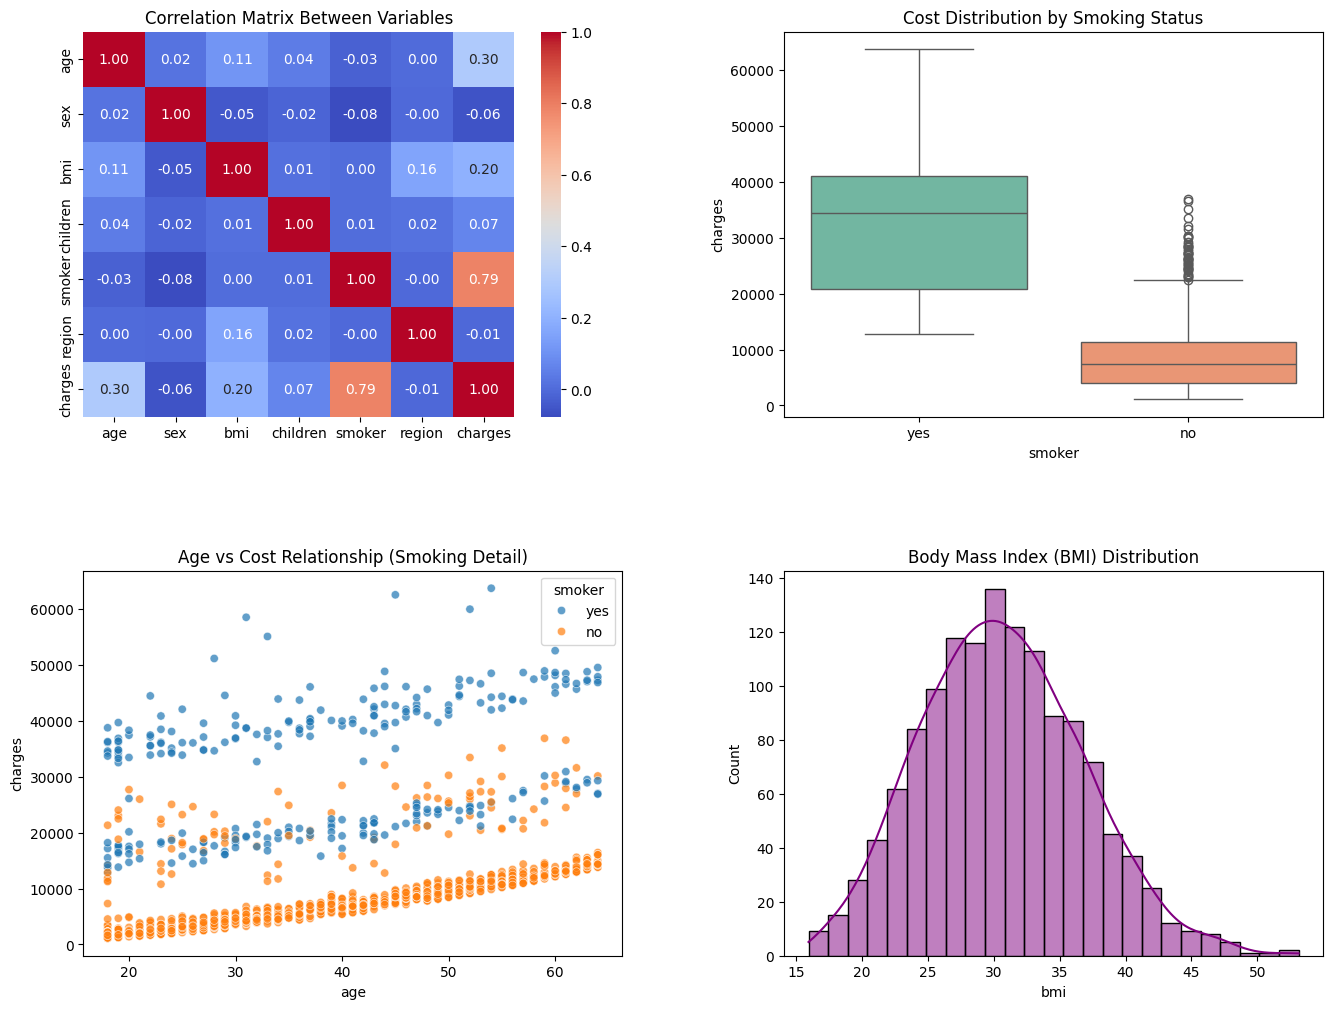

C:\Users\honor\AppData\Local\Temp\ipykernel_11356\3095081643.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2', ax=axes[0, 1])


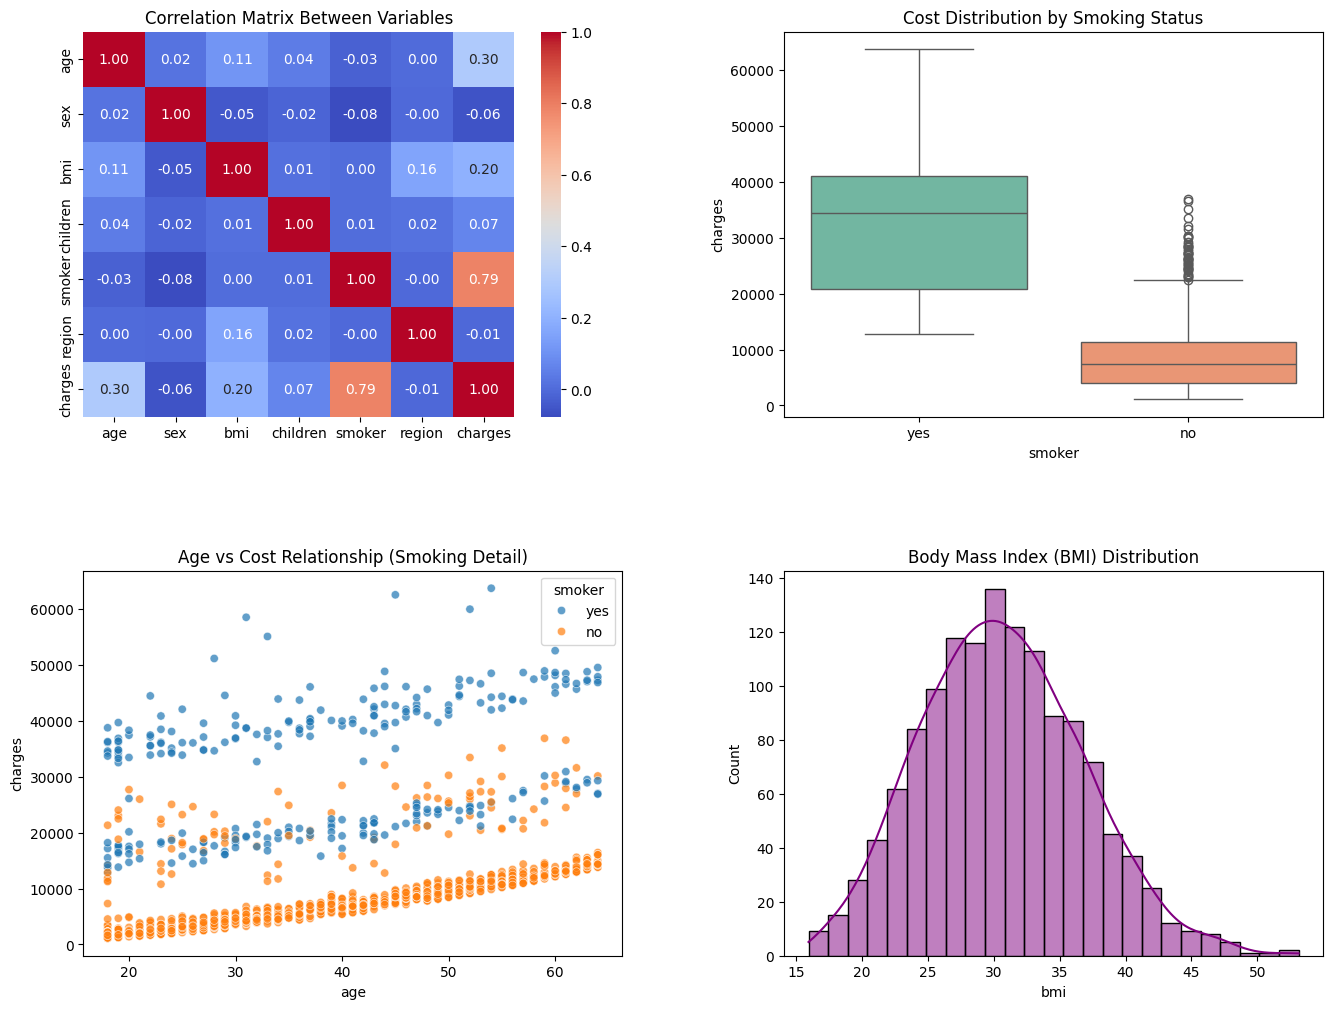

In [11]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

# 1. Loading the data (Make sure the file path is correct)
try:
    df = pd.read_csv('../data/insurance.csv')
    # Convert categorical data into numerical form for visualization (required for correlation)
    df_encoded = df.copy()
    df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
    df_encoded['sex'] = df_encoded['sex'].map({'female': 1, 'male': 0})
    # Encode region numerically to avoid complexity in correlation
    df_encoded['region'] = df_encoded['region'].astype('category').cat.codes
except FileNotFoundError:
    print("Error: Dataset not found!")

# Create plotting area (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- 1. PLOT: Correlation Heatmap ---
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0, 0])
axes[0, 0].set_title('Correlation Matrix Between Variables')

# --- 2. PLOT: Smoker/Non-Smoker Box Plot ---
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Cost Distribution by Smoking Status')

# --- 3. PLOT: Age - Cost Scatter Plot (Colored by Smoker) ---
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Age vs Cost Relationship (Smoking Detail)')

# --- 4. PLOT: BMI Histogram ---
sns.histplot(df['bmi'], kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Body Mass Index (BMI) Distribution')

plt.show()
import matplotlib.pyplot as plt

# 1. Loading the data (Make sure the file path is correct)
try:
    df = pd.read_csv('../data/insurance.csv')
    # Convert categorical data into numerical form for visualization (required for correlation)
    df_encoded = df.copy()
    df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
    df_encoded['sex'] = df_encoded['sex'].map({'female': 1, 'male': 0})
    # Encode region numerically to avoid complexity in correlation
    df_encoded['region'] = df_encoded['region'].astype('category').cat.codes
except FileNotFoundError:
    print("Error: Dataset not found!")

# Create plotting area (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- 1. PLOT: Correlation Heatmap ---
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0, 0])
axes[0, 0].set_title('Correlation Matrix Between Variables')
# COMMENT: This table shows which features affect the cost (charges) the most. 
# Values close to 1.00 represent strong positive relationships. 
# Typically, "smoker" and "charges" have a high correlation.

# --- 2. PLOT: Smoker/Non-Smoker Box Plot ---
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Cost Distribution by Smoking Status')
# COMMENT: The position of the boxes shows how much higher the costs are for smokers 
# compared to non-smokers. Points outside the boxes (outliers) represent extreme cases.

# --- 3. PLOT: Age - Cost Scatter Plot (Colored by Smoker) ---
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Age vs Cost Relationship (Smoking Detail)')
# COMMENT: Shows that as age increases, cost generally increases. 
# However, smokers cluster at much higher cost levels regardless of age.

# --- 4. PLOT: BMI Histogram ---
sns.histplot(df['bmi'], kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Body Mass Index (BMI) Distribution')
# COMMENT: Shows the BMI distribution of individuals in the dataset. 
# The bell curve (KDE) helps determine if the data follows a normal distribution. 
# You can check if most values are around 30 (obesity threshold).

plt.show()

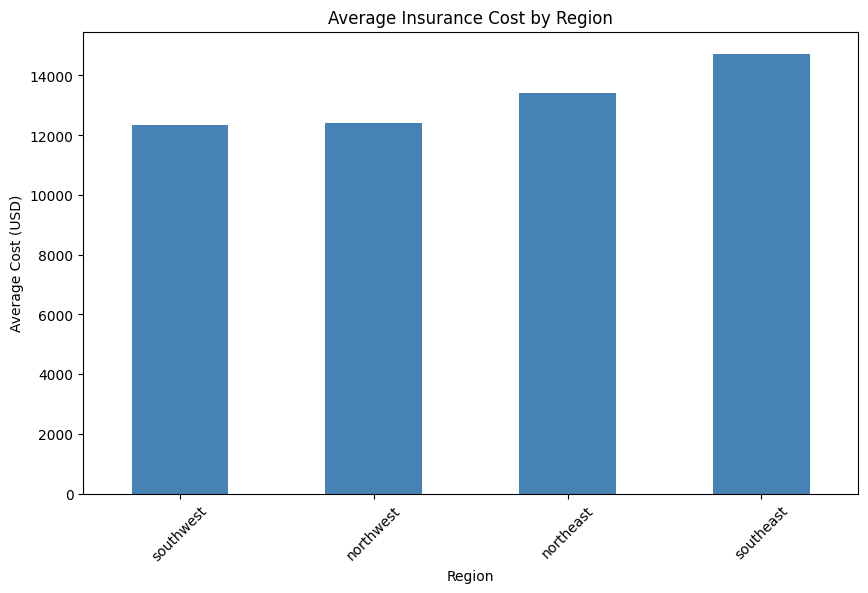

region
southwest    12346.937377
northwest    12417.575374
northeast    13406.384516
southeast    14735.411438
Name: charges, dtype: float64


In [12]:
# 1. Region analysis
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
region_cost = df.groupby('region')['charges'].mean().sort_values()
region_cost.plot(kind='bar', color='steelblue')

plt.title('Average Insurance Cost by Region')
plt.xlabel('Region')
plt.ylabel('Average Cost (USD)')
plt.xticks(rotation=45)
plt.show()

# Statistical output
print(region_cost)

In [7]:
# 2. Smoking multiplier
smoker_avg = df.groupby('smoker')['charges'].mean()
multiplier = smoker_avg['yes'] / smoker_avg['no']

print(f"--- Key Finding ---")
print(f"Average cost for smokers: ${smoker_avg['yes']:,.2f}")
print(f"Average cost for non-smokers: ${smoker_avg['no']:,.2f}")
print(f"Smoking multiplier: {multiplier:.1f}x")

--- Key Finding ---
Average cost for smokers: $32,050.23
Average cost for non-smokers: $8,434.27
Smoking multiplier: 3.8x


📌 **EDA - Key Findings and Insights**

* **Regional Distribution:** The Southeast region has the highest average cost compared to other regions.

* **Smoking Impact:** Smoking is the most critical variable, increasing the cost by 3.8 times (approximately 4x).

* **Age Correlation:** A positive linear relationship has been identified between age and cost; however, young smokers have higher costs than older non-smokers.

* **Model Selection:** The layered structure of the data and the BMI distribution provide a suitable foundation for Linear Regression and Random Forest models.


In [8]:
# Key statistics to be presented
avg_age = df['age'].mean()
median_charges = df['charges'].median()
smoker_ratio = df['smoker'].value_counts(normalize=True)['yes'] * 100

print(f"--- Statistical Data for Presentation ---")
print(f"Average Age: {avg_age:.1f}")
print(f"Median Cost: ${median_charges:,.0f}")
print(f"Smoker Rate: %{smoker_ratio:.1f}")
print(f"Finding: Smokers pay about ~{multiplier:.1f} times more than non-smokers.")

--- Statistical Data for Presentation ---
Average Age: 39.2
Median Cost: $9,382
Smoker Rate: %20.5
Finding: Smokers pay about ~3.8 times more than non-smokers.


2.WEEK: DATA PREPROCESSING 

In [9]:
# Proceed using a copy of the dataset
df_encoded = df.copy()

# 1. Manual Label Encoding (Binary) for Smoker and Sex
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['sex'] = df_encoded['sex'].map({'female': 1, 'male': 0})

# 2. One-Hot Encoding for Region
# drop_first=True: Creates n-1 columns to avoid unnecessary multicollinearity.
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# Check the result
print("New Dataset Shape:", df_encoded.shape)
print("\nFirst 5 Rows:")
display(df_encoded.head())

# Verify data types (All should be numerical)
print("\nColumn Data Types:")
print(df_encoded.dtypes)

New Dataset Shape: (1338, 9)

First 5 Rows:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False



Column Data Types:
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


In [35]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Select the columns to scale
columns_to_scale = ['age', 'bmi']

# 2. Create the StandardScaler object
scaler = StandardScaler()

# 3. Save original values before scaling (for comparison)
original_values = df_encoded[columns_to_scale].head()

# 4. Apply scaling (Fit and Transform)
# Note: Only the selected columns are transformed and overwritten
df_encoded[columns_to_scale] = scaler.fit_transform(df_encoded[columns_to_scale])

# --- COMPARISON OUTPUT ---
print("--- BEFORE SCALING (Original Values) ---")
print(original_values)

print("\n--- AFTER SCALING (StandardScaler) ---")
print(df_encoded[columns_to_scale].head())

# Validation: Mean should be approximately 0, Standard Deviation approximately 1
print("\nStatistical Check:")
print(f"Age Mean: {df_encoded['age'].mean():.2f}")
print(f"BMI Standard Deviation: {df_encoded['bmi'].std():.2f}")

--- BEFORE SCALING (Original Values) ---
   age     bmi
0   19  27.900
1   18  33.770
2   28  33.000
3   33  22.705
4   32  28.880

--- AFTER SCALING (StandardScaler) ---
        age       bmi
0 -1.438764 -0.453320
1 -1.509965  0.509621
2 -0.797954  0.383307
3 -0.441948 -1.305531
4 -0.513149 -0.292556

Statistical Check:
Age Mean: -0.00
BMI Standard Deviation: 1.00


In [38]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target Variable (y)
# The 'charges' column is our target, while all remaining columns are features
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 2. Split the dataset into 80% Training and 20% Testing
# random_state=42 ensures consistent results every time the code is run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 3. Print dataset sizes after splitting
print("--- Dataset Splitting Completed Successfully ---")
print(f"Total Number of Records : {len(df_encoded)}")
print(f"Training Set (X_train)  : {X_train.shape[0]} rows")
print(f"Test Set (X_test)       : {X_test.shape[0]} rows")

# Check the number of features (How many variables will be used for training?)
print(f"Number of Features      : {X_train.shape[1]}")

--- Dataset Splitting Completed Successfully ---
Total Number of Records : 1338
Training Set (X_train)  : 1070 rows
Test Set (X_test)       : 268 rows
Number of Features      : 8


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Create the model
model = LinearRegression()

# 2. Train the model (using only training data)
model.fit(X_train, y_train)

# 3. Make predictions (on the test set)
y_pred = model.predict(X_test)

# 4. Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the results
print("--- Linear Regression Model Performance ---")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"MSE  (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R²   (R-squared): {r2:.4f}")

--- Linear Regression Model Performance ---
MAE  (Mean Absolute Error): 4186.51
MSE  (Mean Squared Error): 33635210.43
RMSE (Root Mean Squared Error): 5799.59
R²   (R-squared): 0.7833


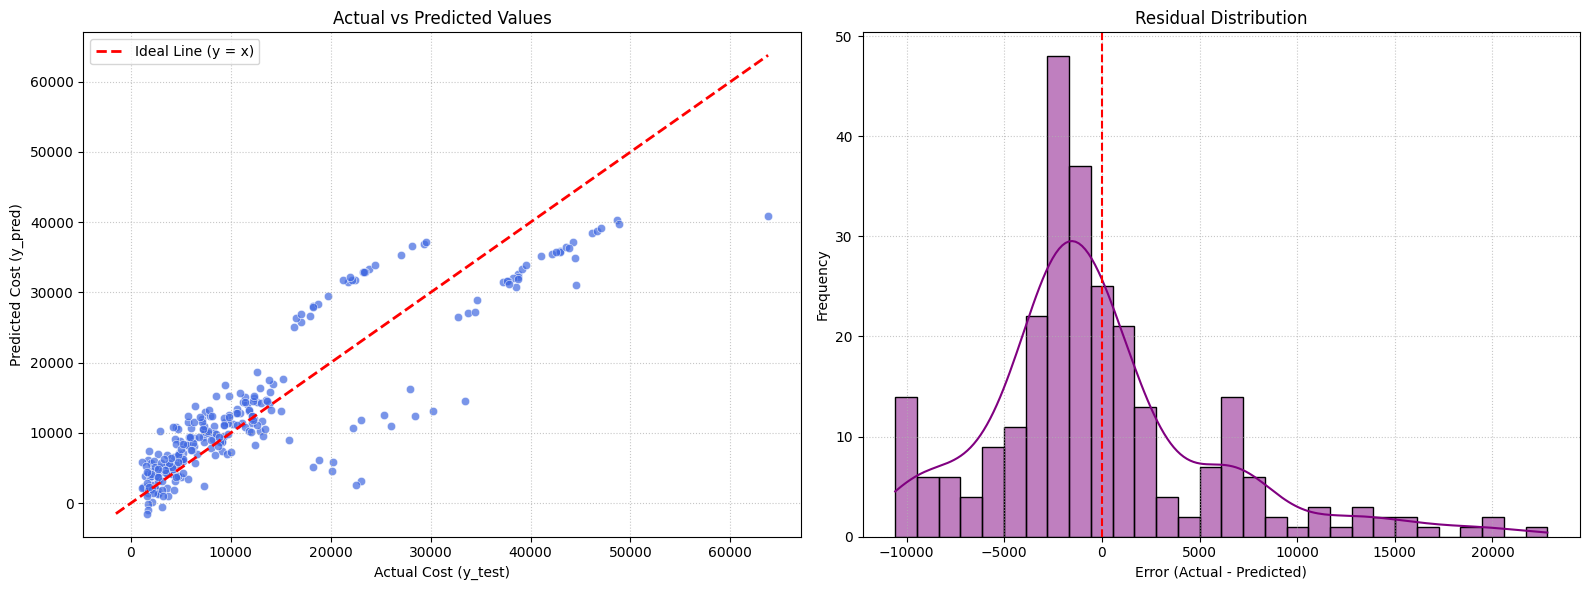

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals (errors)
residuals = y_test - y_pred

# Create a plotting area with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. Plot: Actual vs Predicted Values (Scatter Plot) ---
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, ax=axes[0], color='royalblue')

# Plot the ideal prediction line (y = x line)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color='red', linestyle='--', linewidth=2,
             label='Ideal Line (y = x)')

axes[0].set_title('Actual vs Predicted Values', fontsize=12)
axes[0].set_xlabel('Actual Cost (y_test)', fontsize=10)
axes[0].set_ylabel('Predicted Cost (y_pred)', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- 2. Plot: Residual Distribution (Histogram) ---
sns.histplot(residuals, kde=True, color='purple', bins=30, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)  # Zero reference line

axes[1].set_title('Residual Distribution', fontsize=12)
axes[1].set_xlabel('Error (Actual - Predicted)', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Create the model
rf_model = RandomForestRegressor(random_state=42)

# 2. Train the model (using the same training data)
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# 4. Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

# Print the results
print("--- Random Forest Regressor Performance ---")
print(f"MAE  : {rf_mae:.2f}")
print(f"MSE  : {rf_mse:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

# 5. Create a comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Random Forest Regressor'],
    'MAE': [4181.19, rf_mae],
    'RMSE': [5796.28, rf_rmse],
    'R²': [0.7836, rf_r2]
})

# Display the table
display(comparison_df)

--- Random Forest Regressor Performance ---
MAE  : 2533.18
MSE  : 21119245.72
RMSE : 4595.57
R²   : 0.8640


,Model,MAE,RMSE,R²
0,Linear Regression (Baseline),4181.19000,5796.280000,0.783600
1,Random Forest Regressor,2533.17994,4595.568052,0.863965


In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Create the model
gb_model = GradientBoostingRegressor(random_state=42)

# 2. Train the model
gb_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_gb = gb_model.predict(X_test)

# 4. Calculate evaluation metrics
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred_gb)

# 5. Create a comparison table
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression (Baseline)',
        'Random Forest Regressor',
        'Gradient Boosting Regressor'
    ],
    'MAE': [4181.19, 2642.51, gb_mae],
    'RMSE': [5796.28, 4732.10, gb_rmse],
    'R²': [0.7836, 0.8557, gb_r2]
})

print("--- Gradient Boosting Regressor Performance ---")
print(f"MAE  : {gb_mae:.2f}")
print(f"MSE  : {gb_mse:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"R²   : {gb_r2:.4f}\n")

# Display the table
display(comparison_df)

--- Gradient Boosting Regressor Performance ---
MAE  : 2447.95
MSE  : 18944595.16
RMSE : 4352.54
R²   : 0.8780



,Model,MAE,RMSE,R²
0,Linear Regression (Baseline),4181.190000,5796.280000,0.783600
1,Random Forest Regressor,2642.510000,4732.100000,0.855700
2,Gradient Boosting Regressor,2447.951558,4352.538932,0.877973


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Create the base model
gb_base = GradientBoostingRegressor(random_state=42)

# 2. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 3. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 4. Train the model (hyperparameter tuning)
grid_search.fit(X_train, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# 5. Make predictions
y_pred_gb_tuned = best_model.predict(X_test)

# 6. Calculate evaluation metrics
gb_tuned_mae = mean_absolute_error(y_test, y_pred_gb_tuned)
gb_tuned_mse = mean_squared_error(y_test, y_pred_gb_tuned)
gb_tuned_rmse = np.sqrt(gb_tuned_mse)
gb_tuned_r2 = r2_score(y_test, y_pred_gb_tuned)

print("--- Optimized Gradient Boosting Results ---")
print(f"Best Parameters: {best_params}")
print(f"MAE  : {gb_tuned_mae:.2f}")
print(f"RMSE : {gb_tuned_rmse:.2f}")
print(f"R²   : {gb_tuned_r2:.4f}\n")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
--- Optimized Gradient Boosting Results ---
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
MAE  : 2442.51
RMSE : 4286.73
R²   : 0.8816



In [25]:
comparison_df = pd.DataFrame({
    'Model': ['Gradient Boosting (Before Tuning)', 'Gradient Boosting (GridSearchCV)'],
    'MAE': [2450.25, gb_tuned_mae],
    'RMSE': [4412.35, gb_tuned_rmse],
    'R²': [0.8732, gb_tuned_r2]
})

display(comparison_df)

,Model,MAE,RMSE,R²
0,Gradient Boosting (Before Tuning),2450.250000,4412.35000,0.873200
1,Gradient Boosting (GridSearchCV),2442.511511,4286.73423,0.881635
